## Defining CLASS and loading files!

In [1]:
import numpy as np
import pandas as pd
import pickle
from mpi4py import MPI
import os
import sys
from tqdm import tqdm
from collections import defaultdict
import dill
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/library_snapshot')
import sys
import os
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/')
# from library_snapshot import bulk_velocity # For the x-y analysis
from bulk_velocity_pylians import bulk_calculation_pylians
import readsnap
# from analysis_functions import perform_analysis
# from analysis_functions import load_halo_data
from analysis_functions import *
# from computation_xy import *
from Cross_spectra_computation_pylians import cross_power_spectra_pylians
import MAS_library as MASL
import Pk_library as PKL
import matplotlib.pyplot as plt
import readgadget
import readsnap

# Loading CLASS files

In [6]:
def nested_dict(n, type):
    if n==1:
        defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))

data = nested_dict(6, list);


redshifts_class = [1000, 100, 50, 30,20, 10, 9, 8, 7, 6 , 5, 4, 3, 2.5, 2, 1.5, 1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0001, 0]

sims = ["0.0ev", "0.15ev", "0.3ev", "0.6ev", "0.9ev"]
for z in redshifts_class:
    for sim in sims:
        z_index = redshifts_class.index(z)
        # print(sim[:-2])
        data['tk']['class'][sim][z] = np.loadtxt("./../..//runs_class/Runs_class_all/output_"+str(sim[:-2])+"/z"+str(z_index+1)+"_tk.dat")

# Loading particles from small simulations

In [8]:
snap1_dir = "./../../simulations/L_1024_Ngrid_128/0.3ev/output/snap002_cdm"
header   = readsnap.snapshot_header(snap1_dir)
Nall     = header.nall 
ptype    = header.format #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
pos_type1 = readsnap.read_block(snap1_dir, "POS ", 1, True,  0, False, False, Nall)/1000. # Internal unit is Kpc/h and we should convert to Mpc/h
vel_type1 = readsnap.read_block(snap1_dir, "VEL ", 1, True,  0, False, False, Nall)
print(f"{snap1_dir}, {Nall} which should be {128**3}, {ptype}")
print(f" Print of some positions")
print(pos_type1[1200:1210])
print(f" Print of some velocities")
print(vel_type1[:10])

#### Loading the second types of particles
# snap2_dir = "./../../simulations/L_1024_Ngrid_128/0.3ev/output/snap002_ncdm0"
# header2   = readsnap.snapshot_header(snap2_dir)
# Nall2     = header.nall 
# ptype2    = header.format #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)
# pos_type2 = readsnap.read_block(snap2_dir, "POS ", 1, True,  0, False, False, Nall2)/1000. # Internal unit is Kpc/h and we should convert to Mpc/h
# vel_type2 = readsnap.read_block(snap2_dir, "VEL ", 1, True,  0, False, False, Nall2)

# print(f"{snap2_dir}, {Nall2} which should be {128**3}, {ptype2}")

./../../simulations/L_1024_Ngrid_128/0.3ev/output/snap002_cdm, [      0 2097152       0       0       0       0] which should be 2097152, 1
 Print of some positions
[[1.0236545e+03 7.6240463e+01 7.7543092e+00]
 [1.2510270e+00 8.3932877e+01 4.6360002e+00]
 [9.3719876e-01 8.2869873e+01 7.4775853e+00]
 [1.7683932e+00 8.5595123e+01 1.3399564e+00]
 [9.2118320e+00 8.4708374e+01 4.2593627e+00]
 [1.5354821e+01 8.6735771e+01 4.2657690e+00]
 [9.6270599e+00 8.4688446e+01 7.5939016e+00]
 [9.7229948e+00 8.5360023e+01 6.3845903e-01]
 [2.2280962e+01 8.6475548e+01 2.4572988e+00]
 [2.0960175e+01 8.7806580e+01 8.0146198e+00]]
 Print of some velocities
[[-503.7166   -203.07364   202.45586 ]
 [-377.93948  -291.0983    267.19232 ]
 [-457.77612  -329.23737   274.07523 ]
 [-340.4124   -327.45786   241.57785 ]
 [ -42.945393 -308.6748    225.01292 ]
 [  31.58072  -284.03073   215.99889 ]
 [  73.03356  -212.8089    240.35867 ]
 [ 119.52718  -122.610374  302.2975  ]
 [-194.2035   -102.2559    350.21008 ]
 [-157.

# Let's construct the density and velocity/momentum fields using Pylians!

In [4]:
# grid    = 512    #the 3D field will have grid x grid x grid voxels
# BoxSize = 1024.0 #Mpc/h ; size of box
# MAS     = 'TSC'  #mass-assigment scheme
# verbose = False   #print information on progress
# axis = 0
# #######################################
# rho_type1 = np.zeros((grid,grid,grid), dtype=np.float32)
# MASL.MA(pos_type1, rho_type1, BoxSize, MAS, verbose=verbose)
# delta_type1 = rho_type1/np.mean(rho_type1, dtype=np.float64);  delta_type1 -= 1.0 ### We have constructed the density for the field1
# ### Velocity field construction
# # gas masses of the particles (masses goes from 0 to 1)
# # define 3D density field
# Px_1 = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
# Py_1 = np.zeros((grid,grid,grid), dtype=np.float32)
# Pz_1 = np.zeros((grid,grid,grid), dtype=np.float32)
# MASL.MA(pos_type1, Px_1, BoxSize, MAS, W=vel_type1[:,0], verbose=verbose)
# MASL.MA(pos_type1, Py_1, BoxSize, MAS, W=vel_type1[:,1], verbose=verbose)
# MASL.MA(pos_type1, Pz_1, BoxSize, MAS, W=vel_type1[:,2], verbose=verbose)
# # at this point, Px contains the effective particle mass *v_x in each voxel
# # Px /= np.mean(Px, dtype=np.float64);  Px -= 1.0 ### We don't do this part!

# #######################################
# #### The same for particles of type 2
# rho_type2 = np.zeros((grid,grid,grid), dtype=np.float32)
# MASL.MA(pos_type2, rho_type2, BoxSize, MAS, verbose=verbose)
# delta_type2 = rho_type2/np.mean(rho_type2, dtype=np.float64);  delta_type2 -= 1.0 ### We have constructed the density for the field1
# ### Velocity field construction
# # gas masses of the particles (masses goes from 0 to 1)
# # define 3D density field
# Px_2 = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
# Py_2 = np.zeros((grid,grid,grid), dtype=np.float32)
# Pz_2 = np.zeros((grid,grid,grid), dtype=np.float32)
# MASL.MA(pos_type2, Px_2, BoxSize, MAS, W=vel_type2[:,0], verbose=verbose)
# MASL.MA(pos_type2, Py_2, BoxSize, MAS, W=vel_type2[:,1], verbose=verbose)
# MASL.MA(pos_type2, Pz_2, BoxSize, MAS, W=vel_type2[:,2], verbose=verbose)
# # at this point, Px contains the effective particle mass *v_x in each voxel
# # Px /= np.mean(Px, dtype=np.float64);  Px -= 1.0 ### We don't do this part!
# # print(Px_correct/Px_1)
# Px_1_correct = Px_1

# Let's compute the density and velocity spectra and compare them with CLASS results

In [5]:
# threads = 1
# axis = 0
# ### Field 1
# Pk = PKL.Pk(delta_type1, BoxSize, axis, MAS, threads, verbose)
# k_den_1       = Pk.k3D
# Pk0_den_1     = Pk.Pk[:,0] #monopole
# # print((Px_correct/Px_1)[:2,:2,:2])
# k_12, Pk_theta_12, Nmodes_12 = PKL.Pk_theta(Px_1, Py_1, Pz_1, BoxSize, axis, MAS, threads)
# # print((Px_correct/Px_1)[:2,:2,:2])


# # print((Px_correct/Px_1)[:2,:2,:2])
# # k_12, Pk_theta_12, Nmodes_12 = PKL.Pk_theta(Px_1, Py_1, Pz_1, BoxSize, axis, MAS, threads)
# # print((Px_correct/Px_1)[:2,:2,:2])
# ### Field 2
# # Pk = PKL.Pk(delta_type2, BoxSize, axis, MAS, threads, verbose)
# # k_den_2       = Pk.k3D
# # Pk0_den_2     = Pk.Pk[:,0] #monopole
# # k_21, Pk_dd0_21, Pk_tt0_21, Pk_dt0_21, Nmodes_11 = PKL.XPk_dv(delta_type2, Px_2, Py_2, Pz_2, BoxSize, axis, MAS, threads)
# # k_22, Pk_theta_22, Nmodes_22 = PKL.Pk_theta(Px_2, Py_2, Pz_2, BoxSize, axis, MAS, threads)

Computing power spectrum of theta...
Time compute modulus = 0.07
Time taken = 0.12 seconds


# Functions for fast calculation

In [6]:
def density_field(delta, pos):
    delta = np.zeros((grid,grid,grid), dtype=np.float32)
    MASL.MA(pos_type1, delta, BoxSize, MAS, verbose=verbose)
    delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0 
    return delta

def velocity_field(pos, vel):
    vx = vel[:,0] #Msun/h
    vy = vel[:,1] #Msun/h
    vz = vel[:,2] #Msun/h
    min_density = 1.e-20
    # define 3D density field
    Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
    Py = np.zeros((grid,grid,grid), dtype=np.float32)
    Pz = np.zeros((grid,grid,grid), dtype=np.float32)

    density = np.zeros((grid,grid,grid), dtype=np.float32)
    MASL.MA(pos, density, BoxSize, MAS, verbose=verbose)
    
    MASL.MA(pos, Px, BoxSize, MAS, W=vx, verbose=verbose)
    MASL.MA(pos, Py, BoxSize, MAS, W=vy, verbose=verbose)
    MASL.MA(pos, Pz, BoxSize, MAS, W=vz, verbose=verbose) 
    Vx = np.where(density > min_density, Px / density, 0)
    Vy = np.where(density > min_density, Py / density, 0)
    Vz = np.where(density > min_density, Pz / density, 0)

    return Vx, Vy, Vz

def momentum_field(pos, vel):
    vx = vel[:,0] #Msun/h
    vy = vel[:,1] #Msun/h
    vz = vel[:,2] #Msun/h
    # define 3D density field
    Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
    Py = np.zeros((grid,grid,grid), dtype=np.float32)
    Pz = np.zeros((grid,grid,grid), dtype=np.float32)
    MASL.MA(pos, Px, BoxSize, MAS, W=vx, verbose=verbose)
    MASL.MA(pos, Py, BoxSize, MAS, W=vy, verbose=verbose)
    MASL.MA(pos, Pz, BoxSize, MAS, W=vz, verbose=verbose) 
    return Px, Py, Pz

def power_momentum_div(delta, velocity_field):
    Px = velocity_field[0]
    Py = velocity_field[1]
    Pz = velocity_field[2]
    k, Pk_dd, Pk_tt, Pk_dt, Nmodes = PKL.XPk_dv(delta, Px, Py, Pz, BoxSize, axis, MAS, threads)
    return k, Pk_dd, Pk_tt, Pk_dt, Nmodes

def power_div(velocity_field):
    Vx = velocity_field[0]
    Vy = velocity_field[1]
    Vz = velocity_field[2]
    k, Pk_theta, Nmodes = PKL.Pk_theta(Vx, Vy, Vz, BoxSize, axis, MAS, threads)
    return k, Pk_theta, Nmodes

# Usuage

In [246]:
# grid    = 128    #the 3D field will have grid x grid x grid voxels
# BoxSize = 1024.0 #Mpc/h ; size of box
# MAS     = 'TSC'  #mass-assigment scheme
# verbose = False   #print information on progress
# axis = 0
# # Px_1 = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
# # Py_1 = np.zeros((grid,grid,grid), dtype=np.float32)
# # Pz_1 = np.zeros((grid,grid,grid), dtype=np.float32)
# # MASL.MA(pos_type1, Px_1, BoxSize, MAS, W=vel_type1[:,0], verbose=verbose)
# # MASL.MA(pos_type1, Py_1, BoxSize, MAS, W=vel_type1[:,1], verbose=verbose)
# # MASL.MA(pos_type1, Pz_1, BoxSize, MAS, W=vel_type1[:,2], verbose=verbose)

# Px_f1, Py_f1, Pz_f1 = momentum_field(pos_type1, vel_type1)
# # Px_correct = Px_f1
# k, Pk_theta_momentum_f1, Nmodes = power_div([Px_f1, Py_f1, Pz_f1])

# Vx_f1, Vy_f1, Vz_f1 = velocity_field(pos_type1, vel_type1)
# # Vx_correct = Vx_f1
# k, Pk_theta_vel_f1, Nmodes = power_div([Vx_f1, Vy_f1, Vz_f1])
# # print(np.shape(Px_f1))



In [247]:
# k_11, Pk_dd0_11, Pk_tt0_11, Pk_dt0_11, Nmodes_11 = PKL.XPk_dv(rho_type1, Px_1, Py_1, Pz_1, BoxSize, axis, MAS, threads)


# #####
# min_density = 1.e-20
# vx = vel_type1[:,0] #Msun/h
# vy = vel_type1[:,1] #Msun/h
# vz = vel_type1[:,2] #Msun/h
# Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
# Py = np.zeros((grid,grid,grid), dtype=np.float32)
# Pz = np.zeros((grid,grid,grid), dtype=np.float32)

# density = np.zeros((grid,grid,grid), dtype=np.float32)
# MASL.MA(pos_type1, density, BoxSize, MAS, verbose=verbose)

# MASL.MA(pos_type1, Px, BoxSize, MAS, W=vx, verbose=verbose)
# MASL.MA(pos_type1, Py, BoxSize, MAS, W=vy, verbose=verbose)
# MASL.MA(pos_type1, Pz, BoxSize, MAS, W=vz, verbose=verbose) 
# Vx = np.where(density > min_density, Px / density, 0)
# Vy = np.where(density > min_density, Py / density, 0)
# Vz = np.where(density > min_density, Pz / density, 0)

# k, Pk_dd_rhov, Pk_tt_rhov, Pk_dt_rhov, Nmodes_rhov = PKL.XPk_dv(density, Vx, Vy, Vz, BoxSize, axis, MAS, threads)

In [41]:
grid    = 32    #the 3D field will have grid x grid x grid voxels
BoxSize = 1024.0 #Mpc/h ; size of box
MAS     = 'TSC'  #mass-assigment scheme
density = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_type1, density, BoxSize, MAS, verbose=verbose)
delta = density/np.mean(density, dtype=np.float64);

print(np.mean(density, dtype=np.float64))
print(np.mean(delta, dtype=np.float64))

63.999984709429555
0.999999995872713


# Velocity spectra comparison

Computing power spectrum of theta...
Time compute modulus = 0.07
Time taken = 0.11 seconds
Computing power spectrum of theta...
Time compute modulus = 0.07
Time taken = 0.11 seconds
Computing power spectrum of theta...
Time compute modulus = 0.07
Time taken = 0.11 seconds
Computing power spectra of the fields...
Time compute modulus = 0.08
Time taken = 0.13 seconds


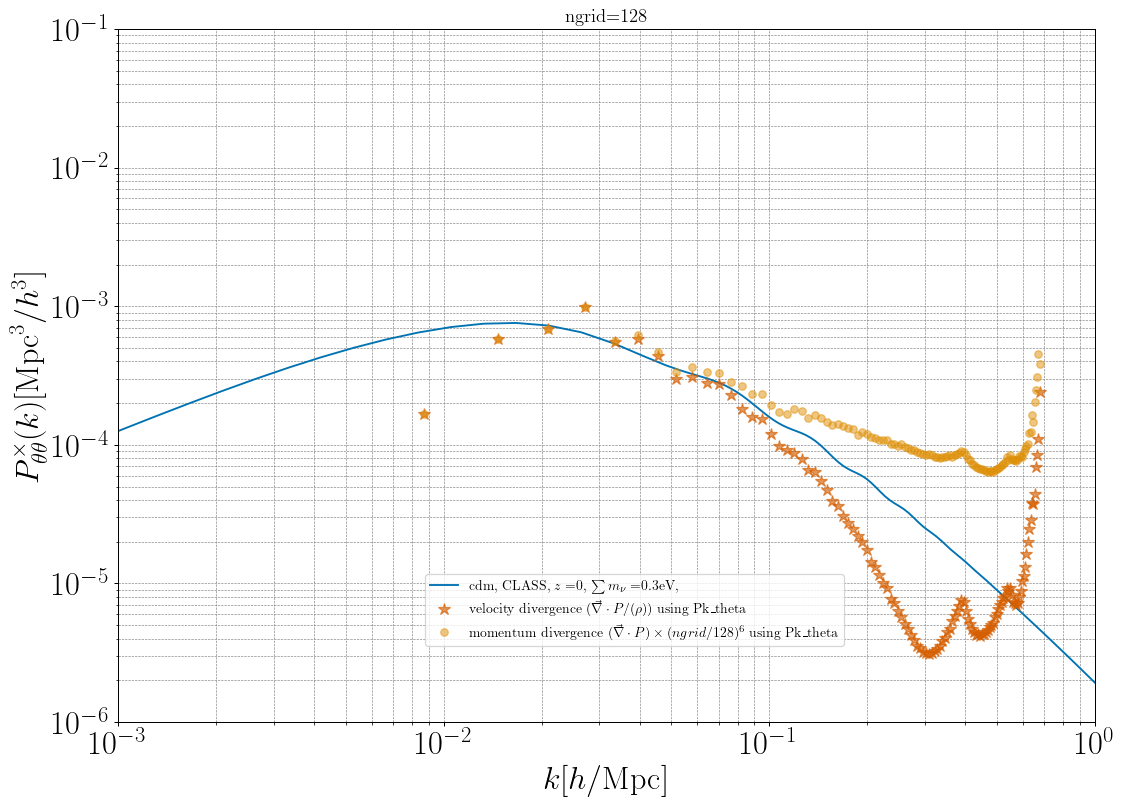

In [13]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;
fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
plt.subplots_adjust(hspace=0.05)

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

z=0
sim="0.3ev"
l=0
data_class = data['tk']['class'][sim][z]
tk_cdm = data_class[:,13]
tk_nu = data_class[:,14]
k_c = data_class[:,0]
normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
p_cdm_class = tk_cdm* tk_cdm * normalization/h**2
p_nu_class = tk_nu* tk_nu * normalization/h**2
ax1.plot(k_c, p_cdm_class, "-", color= Colors[l], label=r"${\rm cdm} $, CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")
# ax1.plot(k_c, p_nu_class, "-", color= Colors[l+1], label=r"$\nu$, CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")


alpha_num = 0.65
c_light = 299792.458 # km/s 
coeff = 1./c_light**2
##### Computing the velocity field and then its divergence as well as its momentum spectrum
pos_type1 = readsnap.read_block(snap1_dir, "POS ", 1, True,  0, False, False, Nall)/1000. # Internal unit is Kpc/h and we should convert to Mpc/h
vel_type1 = readsnap.read_block(snap1_dir, "VEL ", 1, True,  0, False, False, Nall)
grid    = 128    #the 3D field will have grid x grid x grid voxels
BoxSize = 1024.0 #Mpc/h ; size of box
MAS     = 'TSC'  #mass-assigment scheme
verbose = False   #print information on progress
threads = 1
axis = 0
min_density = 1.e-16
# define 3D density field
Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
Py = Px
Pz = Px;
Vx=np.zeros((grid,grid,grid), dtype=np.float32);
Vy = Vx;
Vz=Vx;
density = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_type1, density, BoxSize, MAS, verbose=verbose)
delta = density/np.mean(density, dtype=np.float64); # delta -= 1.0
MASL.MA(pos_type1, Px, BoxSize, MAS, W=vel_type1[:,0], verbose=verbose)
MASL.MA(pos_type1, Py, BoxSize, MAS, W=vel_type1[:,1], verbose=verbose)
MASL.MA(pos_type1, Pz, BoxSize, MAS, W=vel_type1[:,2], verbose=verbose) 
Vx = np.where(density > min_density, Px / delta, 0)
Vy = np.where(density > min_density, Py / delta, 0)
Vz = np.where(density > min_density, Pz / delta, 0)
k, Pk_theta, Nmodes = PKL.Pk_theta(Vx, Vy, Vz, BoxSize, axis, MAS, threads)
# ax1.plot(k, Pk_theta*coeff* (grid/128)**6, "o", color= Colors[l+2], markersize=10, label=r"velocity divergence $(\vec \nabla \cdot  P/(\rho/\bar{\rho}) ) \times (ngrid/128)^6$ using Pk\_theta", alpha=alpha_num)  
#########
Vx = np.where(density > min_density, Px / density, 0)
Vy = np.where(density > min_density, Py / density, 0)
Vz = np.where(density > min_density, Pz / density, 0)
k, Pk_theta, Nmodes = PKL.Pk_theta(Vx, Vy, Vz, BoxSize, axis, MAS, threads)
ax1.plot(k, Pk_theta*coeff * h, "*", color= Colors[l+3], markersize=10, label=r"velocity divergence $(\vec \nabla \cdot  P/(\rho) )$ using Pk\_theta", alpha=alpha_num)  

#########
### Momentum
Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
Py = Px
Pz = Px
density = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_type1, Px, BoxSize, MAS, W=vel_type1[:,0], verbose=verbose)
MASL.MA(pos_type1, Py, BoxSize, MAS, W=vel_type1[:,1], verbose=verbose)
MASL.MA(pos_type1, Pz, BoxSize, MAS, W=vel_type1[:,2], verbose=verbose) 
k, Pk_theta, Nmodes = PKL.Pk_theta(Px, Py, Pz, BoxSize, axis, MAS, threads)
ax1.plot(k, Pk_theta*coeff * (grid/128)**6 * h, "o", color= Colors[l+1], label=r"momentum divergence $(\vec \nabla \cdot P)  \times (ngrid/128)^6$ using Pk\_theta", alpha=0.5)  

#### Momentum through cross
Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
Py = Px
Pz = Px;
Vx=np.zeros((grid,grid,grid), dtype=np.float32);
Vy = Vx;
Vz=Vx;
density = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_type1, density, BoxSize, MAS, verbose=verbose)
rho_norm = density/np.mean(density, dtype=np.float64); delta = rho_norm -  1.0
MASL.MA(pos_type1, Px, BoxSize, MAS, W=vel_type1[:,0], verbose=verbose)
MASL.MA(pos_type1, Py, BoxSize, MAS, W=vel_type1[:,1], verbose=verbose)
MASL.MA(pos_type1, Pz, BoxSize, MAS, W=vel_type1[:,2], verbose=verbose) 
Vx = np.where(density > min_density, Px / density, 0)
Vy = np.where(density > min_density, Py / density, 0)
Vz = np.where(density > min_density, Pz / density, 0)
k, Pk_dd, Pk_tt, Pk_dt, Nmodes = PKL.XPk_dv(delta, Vx, Vy, Vz, BoxSize, axis, MAS, threads)
# ax1.plot(k, Pk_tt*coeff, "^", color= Colors[l], label=r"momentum divergence $(\vec \nabla \cdot \delta\rho v )$ using XPk\_dv", alpha=0.8)  

#### Momentum through cross different definition
# Px = np.zeros((grid,grid,grid), dtype=np.float32) ## Note that we don't have mass weighted here as the masses are all equal. So what we construct is basically N_cell * v_x, which can thought as momentum P_x
# Py = Px
# Pz = Px
# density = np.zeros((grid,grid,grid), dtype=np.float32)
# MASL.MA(pos_type1, density, BoxSize, MAS, verbose=verbose)
# # delta = density/np.mean(density, dtype=np.float64); # delta -= 1.0
# MASL.MA(pos_type1, Px, BoxSize, MAS, W=vel_type1[:,0], verbose=verbose)
# MASL.MA(pos_type1, Py, BoxSize, MAS, W=vel_type1[:,1], verbose=verbose)
# MASL.MA(pos_type1, Pz, BoxSize, MAS, W=vel_type1[:,2], verbose=verbose) 
# k, Pk_dd, Pk_tt, Pk_dt, Nmodes = PKL.XPk_dv(density, Px, Py, Pz, BoxSize, axis, MAS, threads)
# ax1.plot(k, Pk_theta*coeff, "*-", color= Colors[l+6], label=r"momentum divergence $(\vec \nabla \cdot \rho v )$ using XPk\_dv", alpha=0.6)  

ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
ax1.set_ylabel(r'$P^{\times}_{\theta \theta}(k) [{\rm Mpc}^3/h^3]$')
# ax1.legend()
# ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)

ax1.set_title(f"ngrid={grid}", fontsize=15)
ax1.set_ylim(1.e-6, 1.e-1)
ax1.set_xlim((1.e-3, 1))
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True)  # Add grid lines with default settings
ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
# Optional: Customize grid appearance
ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines

plt.show()

Computing power spectra of the fields...
Time compute modulus = 0.08
Time taken = 0.13 seconds
Computing power spectrum of theta...
Time compute modulus = 0.07
Time taken = 0.11 seconds
Computing power spectrum of theta...
Time compute modulus = 0.07
Time taken = 0.11 seconds


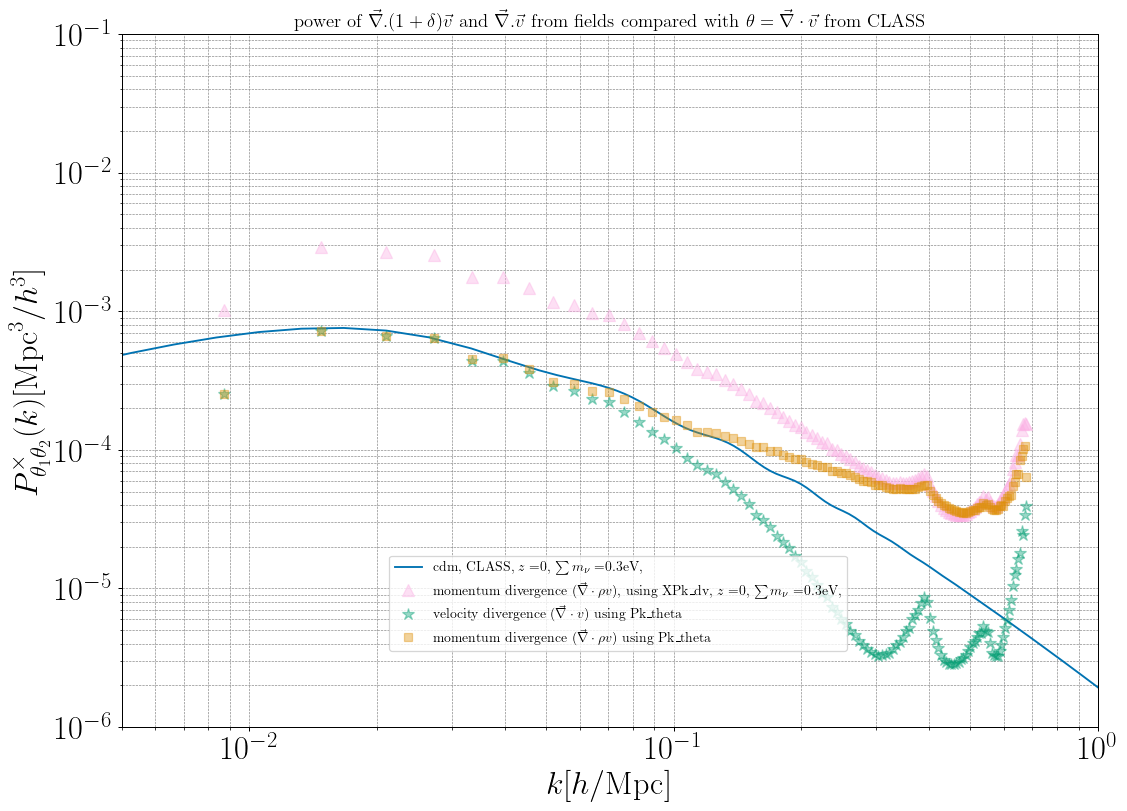

In [17]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;
fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
plt.subplots_adjust(hspace=0.05)

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

z=0
sim="0.3ev"
l=0
data_class = data['tk']['class'][sim][z]
tk_cdm = data_class[:,13]
tk_nu = data_class[:,14]
k_c = data_class[:,0]
normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
p_cdm_class = tk_cdm* tk_cdm * normalization/h**2
p_nu_class = tk_nu* tk_nu * normalization/h**2
ax1.plot(k_c, p_cdm_class, "-", color= Colors[l], label=r"${\rm cdm} $, CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")
# ax1.plot(k_c, p_nu_class, "-", color= Colors[l+1], label=r"$\nu$, CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")


alpha_num = 0.4
c_light = 299792.458 # km/s 
coeff = 1./c_light**2
# ax1.plot(k_12, Pk_tt0_11*coeff, "s", color= Colors[l+2], label=r"momentum*rho using density and momentum in XPk\_dv$z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=alpha_num)   
# ax1.plot(k_12, Pk_theta_12*coeff, "o", color= Colors[l+3], label=r"momentum divergence using Pk\_theta $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.6)   
# ax1.plot(k_11, Pk_theta_12*coeff, "s", color= Colors[l], label=r"cdm- velocity old $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.4)  
# ax1.plot(k, Pk_theta_momentum_f1*coeff, "*", color= Colors[l+2], label=r"momentum divergence$z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.4)  
# ax1.plot(k, Pk_theta_vel_f1*coeff, "*", color= Colors[l+3], label=r"velocity divergence$z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.4) 

##### Computing the velocity field and then its divergence as well as its momentum spectrum
pos_type1 = readsnap.read_block(snap1_dir, "POS ", 1, True,  0, False, False, Nall)/1000. # Internal unit is Kpc/h and we should convert to Mpc/h
vel_type1 = readsnap.read_block(snap1_dir, "VEL ", 1, True,  0, False, False, Nall)
Vx_f1, Vy_f1, Vz_f1 = velocity_field(pos_type1, vel_type1)
rho_type1 = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_type1, rho_type1, BoxSize, MAS, verbose=verbose)
delta_type1 = rho_type1/np.mean(rho_type1, dtype=np.float64);  delta_type1 -= 1.0
### Note that we have put delta not rho!
k, Pk_dd, Pk_tt, Pk_dt, Nmodes = power_momentum_div(rho_type1, [Vx_f1, Vy_f1, Vz_f1])
ax1.plot(k, Pk_tt*coeff, "^", color= Colors[l+6], markersize=9, label=r"momentum divergence $(\vec \nabla \cdot \rho v )$, using XPk\_dv, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=alpha_num)  
Vx_f1, Vy_f1, Vz_f1 = velocity_field(pos_type1, vel_type1)
k, Pk_theta_vel_f1, Nmodes = power_div([Vx_f1, Vy_f1, Vz_f1])
ax1.plot(k, Pk_theta_vel_f1*coeff, "*", color= Colors[l+2], markersize=10, label=r"velocity divergence $(\vec \nabla \cdot  v )$ using Pk\_theta", alpha=alpha_num)  

Px_f1, Py_f1, Pz_f1 = momentum_field(pos_type1, vel_type1)
k, Pk_theta_momentum_f1, Nmodes = power_div([Px_f1, Py_f1, Pz_f1])
ax1.plot(k, Pk_theta_momentum_f1*coeff, "s", color= Colors[l+1], label=r"momentum divergence $(\vec \nabla \cdot \rho v )$ using Pk\_theta", alpha=0.4)  

# ax1.plot(k_21, Pk_theta_22*coeff, "*", color= Colors[l+1], label=r"$\nu$- velocity $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.4)  
# ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
# ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

# ax1.plot(k, k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
# ax1.plot(k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

# ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
# ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
# ax1.legend()
# ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)

ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
ax1.set_ylim(1.e-6, 1.e-1)
ax1.set_xlim((5.e-3, 1))
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True)  # Add grid lines with default settings
ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
# Optional: Customize grid appearance
ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines

plt.show()

## Density spectra comparison

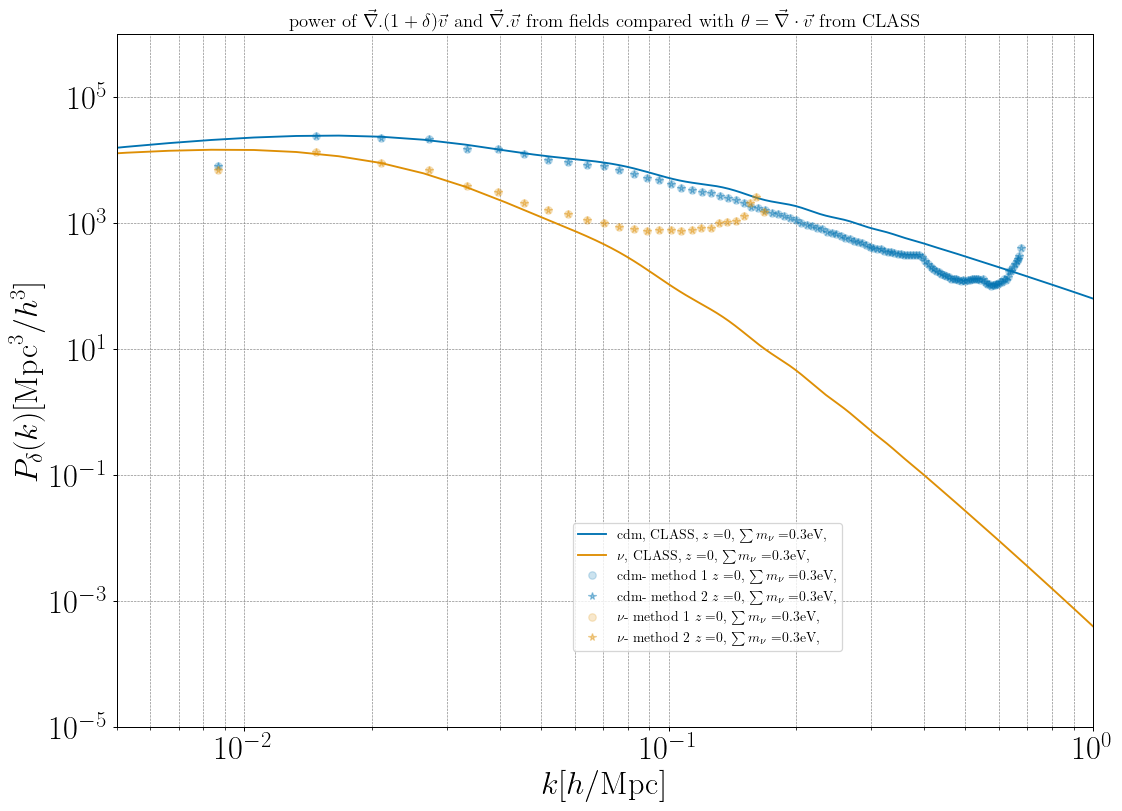

In [244]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;
fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
plt.subplots_adjust(hspace=0.05)

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

z=0
sim="0.3ev"
l=0
data_class = data['tk']['class'][sim][z]
dk_cdm = data_class[:,3]
dk_nu = data_class[:,4]
k_c = data_class[:,0]
normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
p_cdm_class = dk_cdm* dk_cdm * normalization
p_nu_class = dk_nu* dk_nu * normalization
ax1.plot(k_c, p_cdm_class, "-", color= Colors[l], label=r"${\rm cdm} $, CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")
ax1.plot(k_c, p_nu_class, "-", color= Colors[l+1], label=r"$\nu$, CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")
  
ax1.plot(k_den_1, Pk0_den_1, "o", color= Colors[l], label=r"cdm- method 1 $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.2)   
ax1.plot(k_11, Pk_dd0_11, "*", color= Colors[l], label=r"cdm- method 2 $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.4)  

ax1.plot(k_den_2, Pk0_den_2, "o", color= Colors[l+1], label=r"$\nu$- method 1 $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.2)   
ax1.plot(k_21, Pk_dd0_21, "*", color= Colors[l+1], label=r"$\nu$- method 2 $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ", alpha=0.4)  
# ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
# ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

# ax1.plot(k, k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
# ax1.plot(k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

# ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
# ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
ax1.set_ylabel(r'$P_{\delta}(k) [{\rm Mpc}^3/h^3]$')
# ax1.legend()
# ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)

ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
ax1.set_ylim(1.e-5, 1.e6)
ax1.set_xlim((5.e-3, 1))
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True)  # Add grid lines with default settings
ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
# Optional: Customize grid appearance
ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines

plt.show()

In [15]:
print(f"Ratio between the velocity and momentum spectrum (field 2): \n {Pk_theta_22/Pk_tt0_21}")
print(f"Ratio between the velocity and momentum spectrum (field 1): \n {Pk_theta_12/Pk_tt0_11}")

Ratio between the velocity and momentum spectrum (field 2): 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Ratio between the velocity and momentum spectrum (field 1): 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:

density_tmp = data['sub_box_data']['density']
# density2 = data2['sub_box_data']['density']
min_density = 1e-25  # Small positive value
density_tmp2 = np.where(density_tmp <= 0, min_density, density_tmp)
# density2 = np.where(density2 <= 0, min_density, density2)
delta_org = density_tmp2 / np.mean(density_tmp2, dtype=np.float64) - 1.0
# delta2 = density2 / np.mean(density2, dtype=np.float64) - 1.0

Vx = data['sub_box_data']['P_x']
Vy = data['sub_box_data']['P_y']
Vz = data['sub_box_data']['P_z']
# Normalize velocity by density
Vx = np.where(delta_org > min_density, Vx / delta_org, 0)
Vy = np.where(delta_org > min_density, Vy / delta_org, 0)
Vz = np.where(delta_org > min_density, Vz / delta_org, 0)

### field2 velocity fields
# Vx2 = data2['sub_box_data']['P_x']
# Vy2 = data2['sub_box_data']['P_y']
# Vz2 = data2['sub_box_data']['P_z']
# # Normalize velocity by density
# Vx2 = np.where(density2 > min_density, Vx2 / density2, 0)
# Vy2 = np.where(density2 > min_density, Vy2 / density2, 0)
# Vz2 = np.where(density2 > min_density, Vz2 / density2, 0)

axis     = 0       #no RSD
MAS      = 'TSC'   #it assumes the density constrast and velocities have been generated with the same MAS
threads  = 1       #number of openmp threads
verbose = False 
boxsize = 1024

# Let's compute the auto spectra and cross

In [10]:
# k, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta1, Vx1, Vy1, Vz1, delta2, Vx2, Vy2, Vz2, BoxSize, axis, MAS, threads)
# k_12, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta, Vx, Vy, Vz, delta2, Vx2, Vy2, Vz2, boxsize, axis, MAS, threads)

k, Pk_dd0, Pk_tt0, Pk_dt0, Nmodes = PKL.XPk_dv(delta_org/100, Vx, Vy, Vz, boxsize, axis, MAS, threads)
# k, Pk_dd0_2, Pk_tt0_2, Pk_dt0_2, Nmodes = PKL.XPk_dv(delta*1000, Vx, Vy, Vz, boxsize, axis, MAS, threads)

k, Pk_theta, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, boxsize,axis,MAS,threads)
# k2, Pk2, Nmodes = PKL.Pk_theta(Vx2,Vy2,Vz2, boxsize,axis,MAS,threads)

Computing power spectra of the fields...
Time compute modulus = 0.03
Time taken = 0.20 seconds
Computing power spectrum of theta...
Time compute modulus = 0.03
Time taken = 0.18 seconds


In [11]:
Pk_tt0/Pk_theta

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1.])

# Loading CLASS

In [21]:

def nested_dict(n, type):
    if n==1:
        defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))

data_class = nested_dict(6, list);


redshifts_class = [1000, 100, 50, 30,20, 10, 9, 8, 7, 6 , 5, 4, 3, 2.5, 2, 1.5, 1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0001, 0]

sims = ["0.0ev", "0.15ev", "0.3ev", "0.6ev", "0.9ev"]
for z in redshifts_class:
    for sim in sims:
        z_index = redshifts_class.index(z)
        # print(sim[:-2])
        data_class['tk']['class'][sim][z] = np.loadtxt("./../../runs_class/Runs_class_all/output_"+str(sim[:-2])+"/z"+str(z_index+1)+"_tk.dat")



# PLotting them

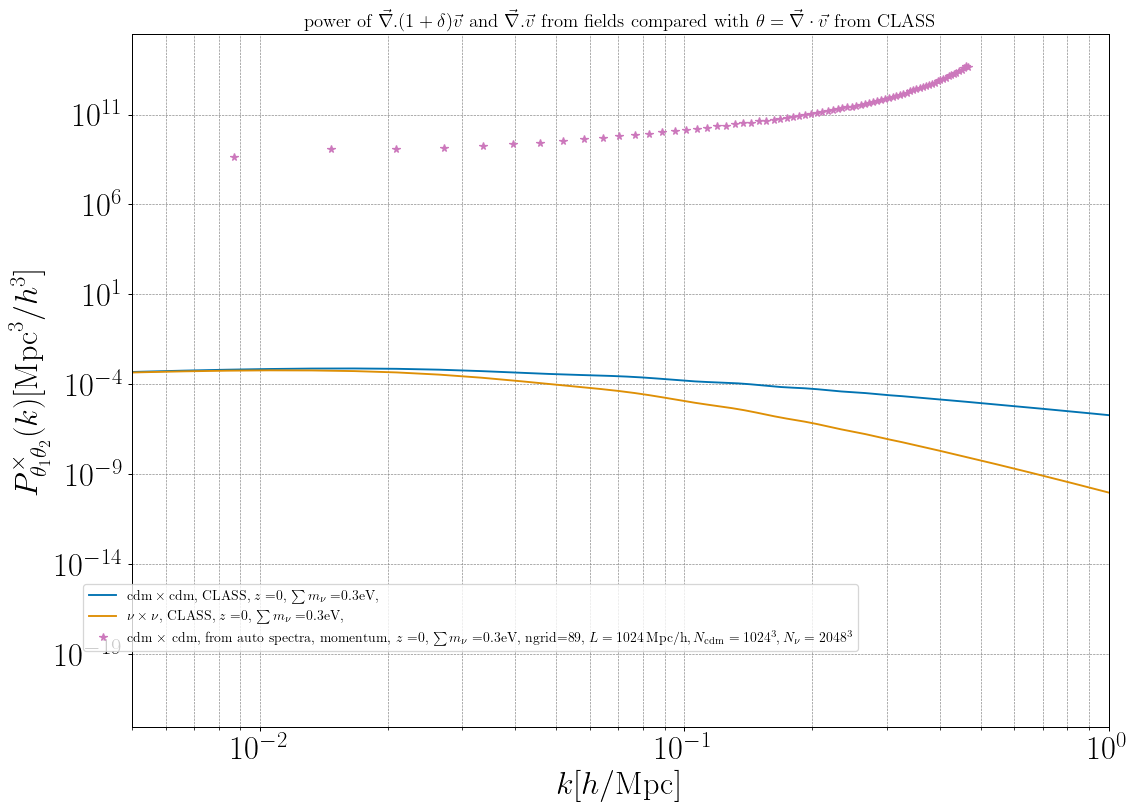

In [25]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;


# specs = ["L_1024_Ngrid_2048", "L_1024_Ngrid_2048_Ngrid_4096" ]
specs = ["L_1024_Ngrid_1024" ]

# nhs = [3, 4, 6, 8]
sims_all = ["0.0ev"]
boxsize = 1024.;
# Loop through each combination of spec, num_halos, Mass_cut, and sim
config_sim_print = [r'$L = 1024 {\rm \, Mpc/h}, N_{\rm cdm} = 1024^3, N_{\nu} = 2048^3$']

line_s  = ["o", "*"]
num_ls = 0

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

alpha_num = 1
l=0
field2 =r"$\nu$"
field1 =r"${\rm cdm}$"
for spec in specs[:1]:
    num_ls = specs.index(spec);
    for z in [0]:
        l=0
        fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
        plt.subplots_adjust(hspace=0.05)
        for sim in sims[2:3]:
        

            data_c = data_class['tk']['class'][sim][z]
            tk_cdm = data_c[:,13]
            tk_nu = data_c[:,14]
            k_c = data_c[:,0]
            normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
            p_nuxnu_class = tk_nu* tk_nu * normalization/h**2
            p_cdmxcdm_class = tk_cdm* tk_cdm * normalization/h**2
            ax1.plot(k_c, p_cdmxcdm_class, "-", color= Colors[l], label=r"${\rm cdm} \times {\rm cdm}$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            ax1.plot(k_c, p_nuxnu_class, "-", color= Colors[l+1], label=rf"$\nu \times \nu$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            c_light = 299792.458 # km/s 
            coeff = 1./c_light**2
            # k_12, Pk_11, Pk_22, Pk_12
            # ax1.plot(k_12, Pk_11 * coeff, "o", color= Colors[l], label=rf"{field1} $\times$ {field1}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k, Pk_theta * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
            ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
            # ax1.legend()
            # ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)
        
            ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
            # ax1.set_ylim(1.e-6, 1.e-2)
            ax1.set_xlim((5.e-3, 1))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.grid(True)  # Add grid lines with default settings
            ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
            # Optional: Customize grid appearance
            ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines
            l=l+1

plt.show()

# Halo

In [188]:
ngrid = 89
# data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_cdm.pickle")
# data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/halo_mass_2e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_halo_mass_2.0e+13.pickle")

data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/halo_mass_1e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_halo_mass_1.0e+13.pickle")
data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/nu/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_nu.pickle")


In [189]:

density = data['sub_box_data']['density']
density2 = data2['sub_box_data']['density']
min_density = 1e-25  # Small positive value
density = np.where(density <= 0, min_density, density)
density2 = np.where(density2 <= 0, min_density, density2)
delta = density / np.mean(density, dtype=np.float64) - 1.0
delta2 = density2 / np.mean(density2, dtype=np.float64) - 1.0

Vx = data['sub_box_data']['P_x']
Vy = data['sub_box_data']['P_y']
Vz = data['sub_box_data']['P_z']
# Normalize velocity by density
Vx = np.where(density > min_density, Vx / density, 0)
Vy = np.where(density > min_density, Vy / density, 0)
Vz = np.where(density > min_density, Vz / density, 0)

### field2 velocity fields
Vx2 = data2['sub_box_data']['P_x']
Vy2 = data2['sub_box_data']['P_y']
Vz2 = data2['sub_box_data']['P_z']
# Normalize velocity by density
Vx2 = np.where(density2 > min_density, Vx2 / density2, 0)
Vy2 = np.where(density2 > min_density, Vy2 / density2, 0)
Vz2 = np.where(density2 > min_density, Vz2 / density2, 0)

axis     = 0       #no RSD
MAS      = 'CIC'   #it assumes the density constrast and velocities have been generated with the same MAS
threads  = 1       #number of openmp threads
verbose = False 
boxsize = 1024

In [190]:
# k, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta1, Vx1, Vy1, Vz1, delta2, Vx2, Vy2, Vz2, BoxSize, axis, MAS, threads)
k_12, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta, Vx, Vy, Vz, delta2, Vx2, Vy2, Vz2, boxsize, axis, MAS, threads)

# k, Pk_dd0, Pk_tt0, Pk_dt0, Nmodes = PKL.XPk_dv(delta, Vx, Vy, Vz, boxsize, axis, MAS, threads)
# k, Pk, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, boxsize,axis,MAS,threads)
# k2, Pk2, Nmodes = PKL.Pk_theta(Vx2,Vy2,Vz2, boxsize,axis,MAS,threads)

Computing power spectra of the fields...
Time compute modulus = 0.03
Time taken = 0.35 seconds


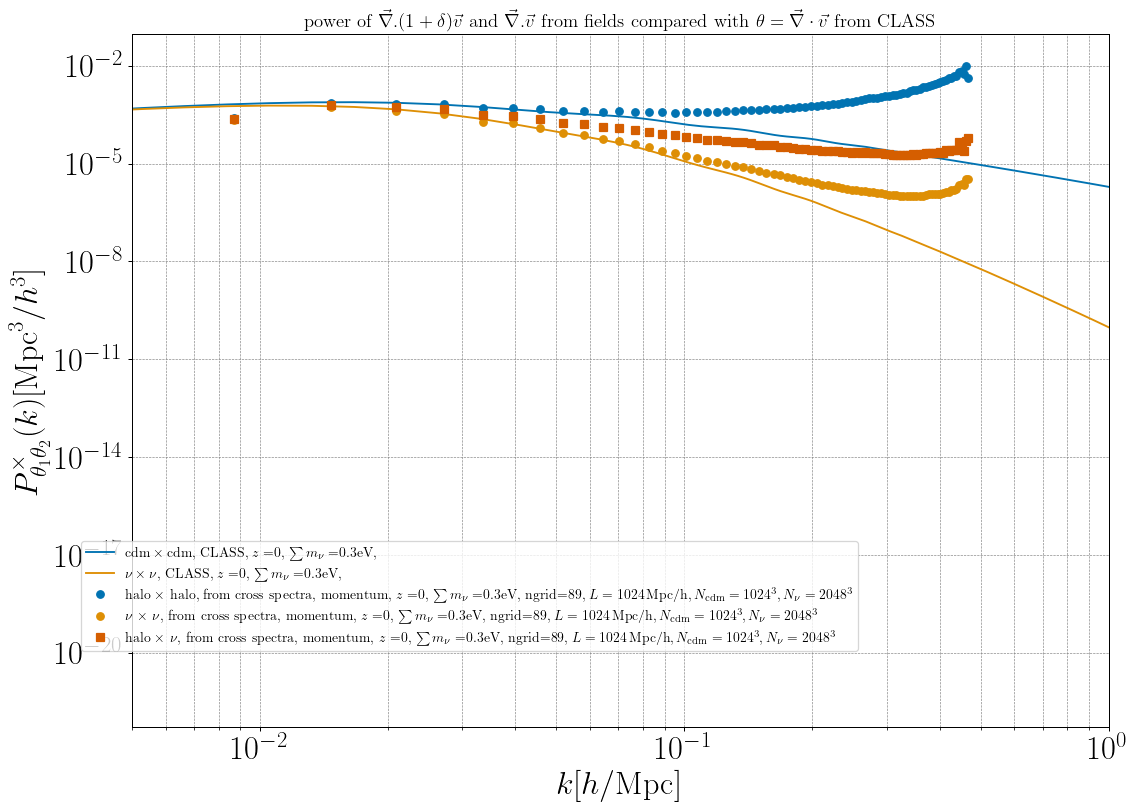

In [191]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;


# specs = ["L_1024_Ngrid_2048", "L_1024_Ngrid_2048_Ngrid_4096" ]
specs = ["L_1024_Ngrid_1024" ]

# nhs = [3, 4, 6, 8]
sims_all = ["0.0ev"]
boxsize = 1024.;
# Loop through each combination of spec, num_halos, Mass_cut, and sim
config_sim_print = [r'$L = 1024 {\rm \, Mpc/h}, N_{\rm cdm} = 1024^3, N_{\nu} = 2048^3$']

line_s  = ["o", "*"]
num_ls = 0

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

alpha_num = 1
l=0
field1 =r"{\rm halo}"
field2 =r"$\nu$"
for spec in specs[:1]:
    num_ls = specs.index(spec);
    for z in [0]:
        l=0
        fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
        plt.subplots_adjust(hspace=0.05)
        for sim in sims[2:3]:
        

            data_c= data_class['tk']['class'][sim][z]
            tk_cdm = data_c[:,13]
            tk_nu = data_c[:,14]
            k_c = data_c[:,0]
            normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
            p_nuxnu_class = tk_nu* tk_nu * normalization/h**2
            p_cdmxcdm_class = tk_cdm* tk_cdm * normalization/h**2
            ax1.plot(k_c, p_cdmxcdm_class, "-", color= Colors[l], label=r"${\rm cdm} \times {\rm cdm}$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            ax1.plot(k_c, p_nuxnu_class, "-", color= Colors[l+1], label=rf"$\nu \times \nu$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            c_light = 299792.458 # km/s 
            coeff = 1./c_light**2
            # k_12, Pk_11, Pk_22, Pk_12
            ax1.plot(k_12, Pk_11 * coeff, "o", color= Colors[l], label=rf"{field1} $\times$ {field1}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k, Pk2 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
            ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
            # ax1.legend()
            # ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)
        
            ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
            # ax1.set_ylim(1.e-6, 1.e-2)
            ax1.set_xlim((5.e-3, 1))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.grid(True)  # Add grid lines with default settings
            ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
            # Optional: Customize grid appearance
            ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines
            l=l+1

plt.show()

# CDM - Halo

In [159]:
ngrid = 89
# data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_cdm.pickle")
# data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_1024/0.3ev/halo_mass_2e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_1024_halo_mass_2.0e+13.pickle")

data = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/cdm/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_cdm.pickle")
data2 = load("./../Run_Bulk_velocities_CIC/L_1024_Ngrid_2048/0.3ev/halo_mass_1e13/output/data_ngrid_89_sim_0.3ev_L_1024_Ngrid_2048_halo_mass_1.0e+13.pickle")


In [160]:

density = data['sub_box_data']['density']
density2 = data2['sub_box_data']['density']
min_density = 1e-25  # Small positive value
density = np.where(density <= 0, min_density, density)
density2 = np.where(density <= 0, min_density, density)
delta = density / np.mean(density, dtype=np.float64) - 1.0
delta2 = density2 / np.mean(density2, dtype=np.float64) - 1.0

Vx = data['sub_box_data']['P_x']
Vy = data['sub_box_data']['P_y']
Vz = data['sub_box_data']['P_z']
# Normalize velocity by density
Vx = np.where(density > min_density, Vx / density, 0)
Vy = np.where(density > min_density, Vy / density, 0)
Vz = np.where(density > min_density, Vz / density, 0)

### field2 velocity fields
Vx2 = data2['sub_box_data']['P_x']
Vy2 = data2['sub_box_data']['P_y']
Vz2 = data2['sub_box_data']['P_z']
# Normalize velocity by density
Vx2 = np.where(density2 > min_density, Vx2 / density2, 0)
Vy2 = np.where(density2 > min_density, Vy2 / density2, 0)
Vz2 = np.where(density2 > min_density, Vz2 / density2, 0)

axis     = 0       #no RSD
MAS      = 'CIC'   #it assumes the density constrast and velocities have been generated with the same MAS
threads  = 1       #number of openmp threads
verbose = False 
boxsize = 1024

In [161]:
# k, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta1, Vx1, Vy1, Vz1, delta2, Vx2, Vy2, Vz2, BoxSize, axis, MAS, threads)
k_12, Pk_11, Pk_22, Pk_12, Nmodes = PKL.XPk_vv(delta, Vx, Vy, Vz, delta2, Vx2, Vy2, Vz2, boxsize, axis, MAS, threads)

# k, Pk_dd0, Pk_tt0, Pk_dt0, Nmodes = PKL.XPk_dv(delta, Vx, Vy, Vz, boxsize, axis, MAS, threads)
# k, Pk, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, boxsize,axis,MAS,threads)
# k2, Pk2, Nmodes = PKL.Pk_theta(Vx2,Vy2,Vz2, boxsize,axis,MAS,threads)

Computing power spectra of the fields...
Time compute modulus = 0.03
Time taken = 0.36 seconds


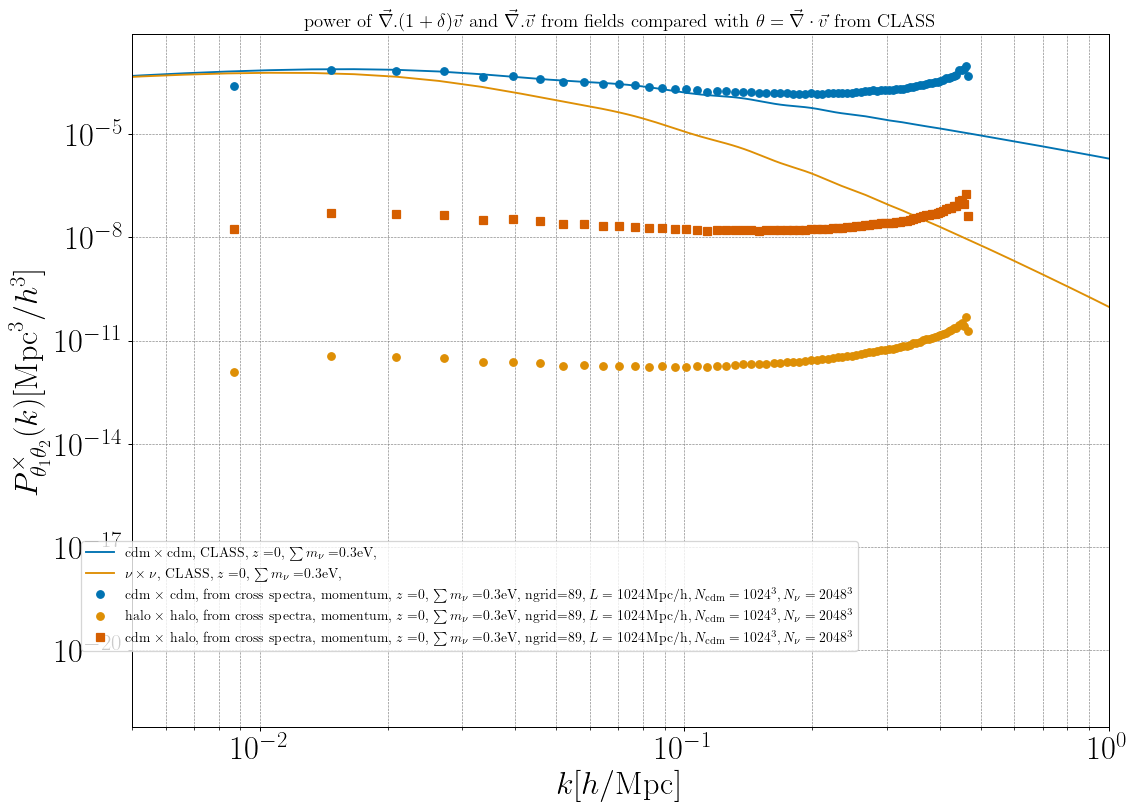

In [163]:
from matplotlib.lines import Line2D
import seaborn as sns

Colors = sns.color_palette("colorblind", 12).as_hex()
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': 26}
plt.rc('font', **font)

markersize = 7; alpha_num = 1;


# specs = ["L_1024_Ngrid_2048", "L_1024_Ngrid_2048_Ngrid_4096" ]
specs = ["L_1024_Ngrid_1024" ]

# nhs = [3, 4, 6, 8]
sims_all = ["0.0ev"]
boxsize = 1024.;
# Loop through each combination of spec, num_halos, Mass_cut, and sim
config_sim_print = [r'$L = 1024 {\rm \, Mpc/h}, N_{\rm cdm} = 1024^3, N_{\nu} = 2048^3$']

line_s  = ["o", "*"]
num_ls = 0

h = 0.67
n_s = 0.9619;
k_p = 0.05/h;
h = 0.67
A_s = 2.215e-9

alpha_num = 1
l=0
field1 =r"{\rm cdm}"
field2 =r"${\rm halo}$"
for spec in specs[:1]:
    num_ls = specs.index(spec);
    for z in [0]:
        l=0
        fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10), dpi=90, sharex=True)
        plt.subplots_adjust(hspace=0.05)
        for sim in sims[2:3]:
        

            data_c= data_class['tk']['class'][sim][z]
            tk_cdm = data_c[:,13]
            tk_nu = data_c[:,14]
            k_c = data_c[:,0]
            normalization =  A_s * (k_c/k_p)**(n_s-1.) * (2.* np.pi**2)/k_c**3    
            p_nuxnu_class = tk_nu* tk_nu * normalization/h**2
            p_cdmxcdm_class = tk_cdm* tk_cdm * normalization/h**2
            ax1.plot(k_c, p_cdmxcdm_class, "-", color= Colors[l], label=r"${\rm cdm} \times {\rm cdm}$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            ax1.plot(k_c, p_nuxnu_class, "-", color= Colors[l+1], label=rf"$\nu \times \nu$"+r", CLASS, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, ")

            c_light = 299792.458 # km/s 
            coeff = 1./c_light**2
            # k_12, Pk_11, Pk_22, Pk_12
            ax1.plot(k_12, Pk_11 * coeff, "o", color= Colors[l], label=rf"{field1} $\times$ {field1}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_22 * coeff, "o", color= Colors[l+1], label=rf"{field2} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            ax1.plot(k_12, Pk_12 * coeff, "s", color= Colors[l+3],label=rf"{field1} $\times$ {field2}"+r", from cross spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k, Pk2 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            # ax1.plot(k, Pk_tt0 * coeff, "*", color= Colors[l+4], label=rf"{field1} $\times$ {field1}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   
            # ax1.plot(k_2, Pk_tt0_2 * coeff, "*", color= Colors[l+5], label=rf"{field2} $\times$ {field2}"+r", from auto spectra, momentum, $z=$"+str(z)+r", $\sum m_{\nu}=$"+str(sim[:-2])+"eV, "+"ngrid="+str(ngrid)+", "+config_sim_print[specs.index(spec)], alpha=alpha_num )   

            ax1.set_xlabel(r'$k [h/{\rm Mpc}]$ ')
            ax1.set_ylabel(r'$P^{\times}_{\theta_1 \theta_2}(k) [{\rm Mpc}^3/h^3]$')
            # ax1.legend()
            # ax1.set_title(r"$M_h \ge \,$" + Mass_cut[5:6]+ r" $\times 10^{" + Mass_cut[10:] + r" } \, M_{\odot}$, " +", $n_h=$"+str(num_halos), fontsize=15)
        
            ax1.set_title(r"power of $\vec \nabla . (1+\delta) \vec v$ and $\vec \nabla . \vec v$ from fields compared with $\theta = \vec \nabla \cdot \vec v$ from CLASS", fontsize=15)
            # ax1.set_ylim(1.e-6, 1.e-2)
            ax1.set_xlim((5.e-3, 1))
            ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.grid(True)  # Add grid lines with default settings
            ax1_legend = ax1.legend(loc='lower right', bbox_to_anchor=(0.75, 0.1), frameon=True, fontsize= 11)
            # Optional: Customize grid appearance
            ax1.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Customize grid lines
            l=l+1

plt.show()